
## Age Group Prediction 

**Target:** Predict age_group → Adult (0) or Senior (1)  
**Dataset:** NHANES health survey features  
---
### Objective
1. Imports & Data Loading
2. Exploratory Data Analysis (EDA)


---
## 1. Imports & Data Loading

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data = pd.read_csv('Train_dataset.csv')
test_data  = pd.read_csv('Test_dataset.csv')

print(f'Train shape: {train_data.shape}')
print(f'Test shape:  {test_data.shape}')
train_data.head()

Train shape: (1966, 9)
Test shape:  (312, 8)


,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


---
## 2. Exploratory Data Analysis (EDA)

Before touching the model, we need to **understand the data deeply**.
EDA answers four questions:
- does it has outliers?
- What does the data look like?
- What's broken or missing?
- Which features might actually help separate Adults from Seniors?

### 2.1 — Target Distribution (Class Imbalance Check)

Training Samples : 1952
Missing Targets  : 14

Class distribution:
age_group
Adult     1638
Senior     314
Name: count, dtype: int64
Adult : 83.9%
Senior: 16.1%


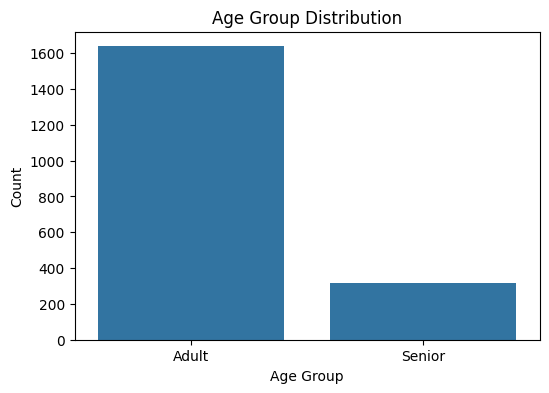

In [3]:
train = train_data.dropna(subset=['age_group']).copy()
print(f"Training Samples : {len(train)}")
print(f"Missing Targets  : {train_data['age_group'].isna().sum()}")

class_counts = train['age_group'].value_counts()
print('\nClass distribution:')
print(class_counts)
adult_pct = (class_counts["Adult"] / len(train)) * 100
senior_pct = (class_counts["Senior"] / len(train)) * 100

print(f"Adult : {adult_pct:.1f}%")
print(f"Senior: {senior_pct:.1f}%")

plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="age_group"
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()


### 2.2 — Missing Values

In [4]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0]

print("Training Data Missing Values:")
print(missing_train)

missing_test = test_data.isnull().sum()
missing_test = missing_test[missing_test > 0]

print("\nTest Data Missing Values:")
print(missing_test)


Training Data Missing Values:
SEQN        12
RIAGENDR    18
PAQ605      13
BMXBMI      18
LBXGLU      13
DIQ010      18
LBXGLT      11
LBXIN        9
dtype: int64

Test Data Missing Values:
SEQN        2
RIAGENDR    2
PAQ605      1
BMXBMI      1
LBXGLU      1
DIQ010      1
LBXGLT      2
LBXIN       1
dtype: int64


### 2.3 — Understanding Categorical Columns

In [5]:
for col in ['RIAGENDR', 'PAQ605', 'DIQ010']:
    print(f'{col} value counts (train):')
    print(train[col].value_counts(dropna=False))
    print()

RIAGENDR value counts (train):
RIAGENDR
2.0    985
1.0    949
NaN     18
Name: count, dtype: int64

PAQ605 value counts (train):
PAQ605
2.0    1595
1.0     343
NaN      13
7.0       1
Name: count, dtype: int64

DIQ010 value counts (train):
DIQ010
2.0    1866
3.0      49
1.0      19
NaN      18
Name: count, dtype: int64



### 2.4 — Continuous Feature Distributions by Age Group

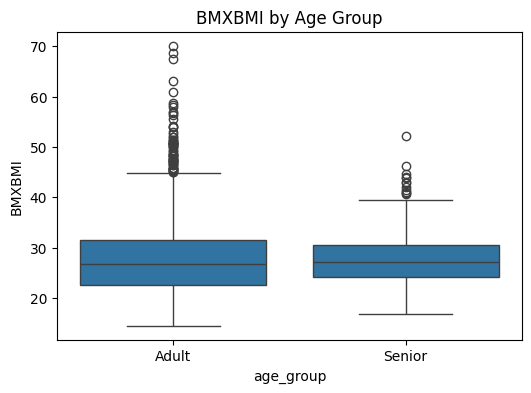

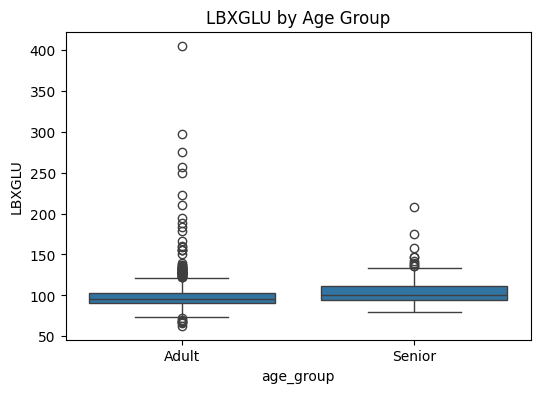

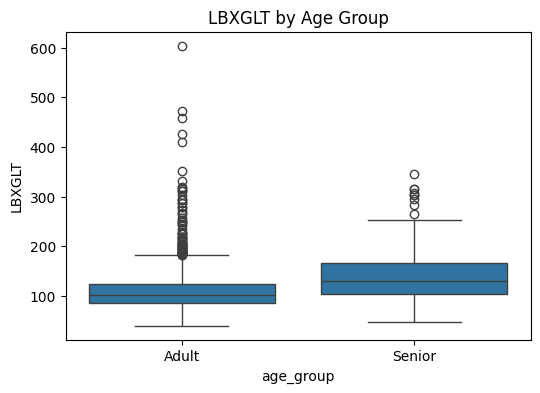

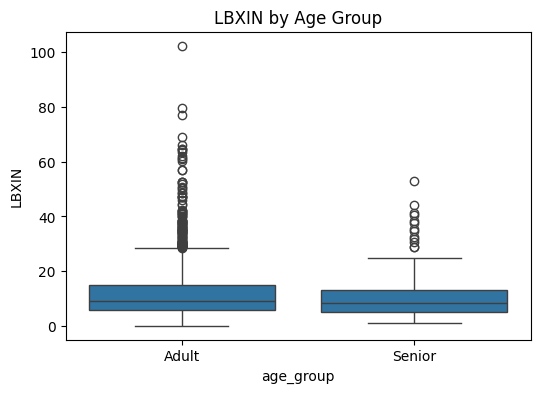

In [6]:
continuous_features = ["BMXBMI", "LBXGLU", "LBXGLT", "LBXIN"]

for col in continuous_features:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=train,
        x="age_group",
        y=col
    )

    plt.title(f"{col} by Age Group")
    plt.show()


### 2.5 — Categorical Features vs Age Group

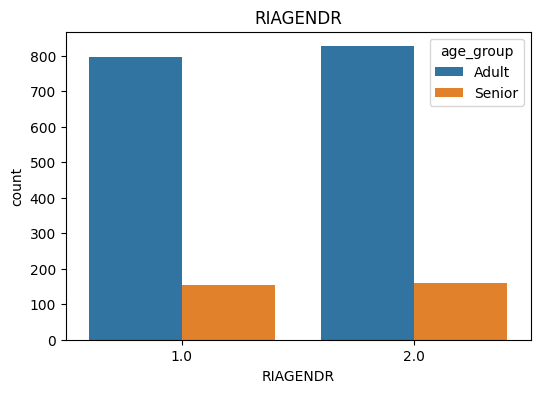

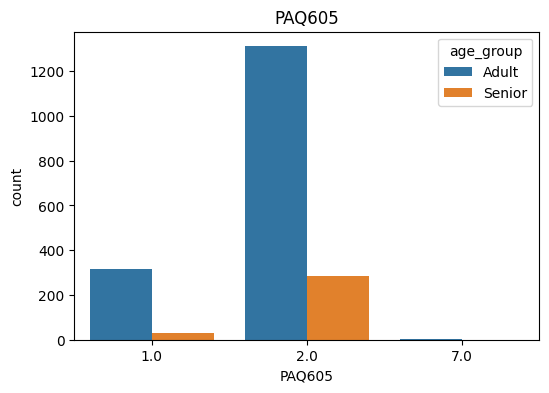

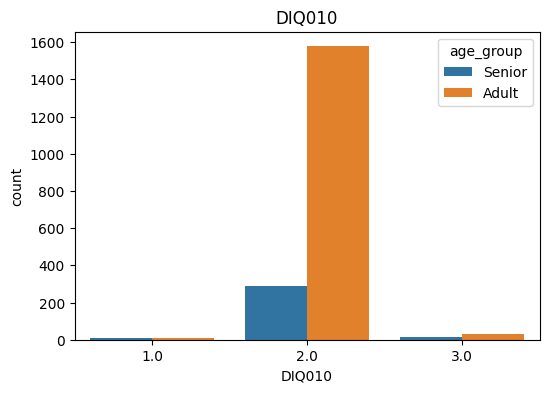

In [7]:
categorical_features = ["RIAGENDR", "PAQ605", "DIQ010"]

for col in categorical_features:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=train,
        x=col,
        hue="age_group"
    )

    plt.title(col)
    plt.show()

### 2.6 — Correlation Heatmap

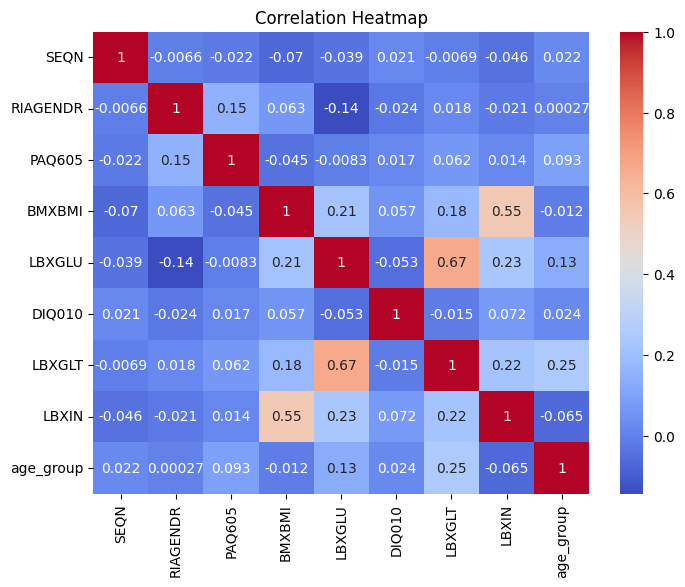

In [8]:

temp = train.copy()
temp["age_group"] = temp["age_group"].map({"Adult": 0, "Senior": 1})

# Correlation
corr = temp.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()